## Import dan konfigurasi 

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42) 

# ── 1. KONFIGURASI WAKTU ──
START_DATE = "2025-12-01 00:00:00"
END_DATE   = "2026-05-31 23:00:00"
FREQ       = "1h"

# ── 2. LINGKUNGAN (Khas Batu, Malang) ──
TEMP_CFG = {'puncak_mean': 24.5, 'lembah_mean': 17.5, 'noise_std': 0.7, 'min': 12.0, 'max': 31.0, 'peak_hour': 13}
HUM_CFG  = {'puncak_mean': 88.0, 'lembah_mean': 66.0, 'noise_std': 2.5, 'min': 45.0, 'max': 99.0, 'peak_hour': 4}

# ── 3. TANAH & LOGIKA POMPA (Paprika) ──
SOIL_CFG = {
    'initial': 58.0, 'trigger_low': 45.0, 'trigger_high': 65.0, 
    'pump_boost': 12.0, 'decay_day': 0.55, 'decay_night': 0.20, 
    'noise_std': 0.30, 'min': 10.0, 'max': 92.0
}
PUMP_CFG = {'min_off_hours': 3, 'max_on_hours': 3}

# ── 4. NUTRISI (Target Optimal) ──
EC_CFG = {'mean': 2.30, 'ar_coef': 0.93, 'noise_std': 0.06, 'pump_dilution': 0.982, 'min': 1.20, 'max': 3.80}
N_CFG  = {'mean': 165.0, 'ar_coef': 0.96, 'noise_std': 1.80, 'min': 80.0, 'max': 240.0}
P_CFG  = {'mean': 62.0, 'ar_coef': 0.97, 'noise_std': 0.90, 'min': 20.0, 'max': 110.0}
K_CFG  = {'mean': 235.0, 'ar_coef': 0.95, 'noise_std': 2.50, 'min': 100.0, 'max': 360.0}

## Helper buat fisika dan agrikultur

In [ ]:
def sinusoidal_daily(timestamps, peak_mean, trough_mean, noise_std, peak_hour, **kwargs):
    """Pola suhu & kelembapan berbasis Cosine."""
    hours = np.array(timestamps.hour + timestamps.minute / 60.0)
    base = (peak_mean + trough_mean) / 2.0
    amplitude = (peak_mean - trough_mean) / 2.0
    signal = base + amplitude * np.cos(2.0 * np.pi * (hours - peak_hour) / 24.0)
    return signal + np.random.normal(0, noise_std, len(timestamps))

def generate_ar1(n, mean, ar_coef, noise_std, min_val, max_val, **kwargs):
    """Simulasi NPK dan EC menggunakan Autoregressive (AR1) yang smooth."""
    series = np.zeros(n)
    series[0] = np.clip(np.random.normal(mean, noise_std), min_val, max_val)
    for t in range(1, n):
        series[t] = (ar_coef * series[t - 1] + 
                     (1.0 - ar_coef) * mean + 
                     np.random.normal(0, noise_std))
    return np.clip(series, min_val, max_val)

def simulate_soil_and_pump(n, timestamps, temp_arr, soil_cfg, pump_cfg):
    """Logika evaporasi tanah dan aksi-reaksi pompa irigasi."""
    soil = np.zeros(n)
    pump = np.zeros(n, dtype=int)
    soil[0] = soil_cfg['initial']
    
    pump_on_count = 0
    pump_off_count = pump_cfg['min_off_hours'] 
    
    for t in range(1, n):
        hour = timestamps[t].hour
        prev_sm = soil[t - 1]
        
        # evaporasi adaptif: Kalau siang suhu Batu tembus panas, tanah lebih cepat kering
        temp_factor = 1.0 + max(0.0, (temp_arr[t] - 22.0) * 0.012)
        decay = (soil_cfg['decay_day'] if 8 <= hour <= 18 else soil_cfg['decay_night']) * temp_factor
        
        # logika Pompa 
        if pump[t - 1] == 1:
            pump_on_count += 1
            pump_off_count = 0
            if prev_sm >= soil_cfg['trigger_high'] or pump_on_count >= pump_cfg['max_on_hours']:
                pump[t] = 0
                pump_on_count = 0
            else:
                pump[t] = 1
        else:
            pump_off_count += 1
            pump_on_count = 0
            if prev_sm < soil_cfg['trigger_low'] and pump_off_count >= pump_cfg['min_off_hours']:
                pump[t] = 1
                pump_off_count = 0
            else:
                pump[t] = 0
                
        # Efek fisika tanah saat disiram vs mengering
        noise = np.random.normal(0, soil_cfg['noise_std'])
        if pump[t] == 1:
            soil[t] = prev_sm + soil_cfg['pump_boost'] - decay + noise
        else:
            soil[t] = prev_sm - decay + noise
            
        soil[t] = np.clip(soil[t], soil_cfg['min'], soil_cfg['max'])
        
    return soil, pump

## eksekusi data dan generate

In [19]:
print("Generating dataset")
timestamps = pd.date_range(start=START_DATE, end=END_DATE, freq=FREQ)
n = len(timestamps)

# cuaca Udara
suhu = np.clip(
    sinusoidal_daily(
        timestamps, 
        peak_mean=TEMP_CFG['puncak_mean'], 
        trough_mean=TEMP_CFG['lembah_mean'], 
        noise_std=TEMP_CFG['noise_std'], 
        peak_hour=TEMP_CFG['peak_hour']
    ), 
    TEMP_CFG['min'], 
    TEMP_CFG['max']
)

kelembapan = np.clip(
    sinusoidal_daily(
        timestamps, 
        peak_mean=HUM_CFG['puncak_mean'], 
        trough_mean=HUM_CFG['lembah_mean'], 
        noise_std=HUM_CFG['noise_std'], 
        peak_hour=HUM_CFG['peak_hour']
    ), 
    HUM_CFG['min'], 
    HUM_CFG['max']
)

# tanah & Pompa
tanah, pompa = simulate_soil_and_pump(n, timestamps, suhu, SOIL_CFG, PUMP_CFG)

# nutrisi
ec = generate_ar1(
    n, 
    mean=EC_CFG['mean'], 
    ar_coef=EC_CFG['ar_coef'], 
    noise_std=EC_CFG['noise_std'], 
    min_val=EC_CFG['min'], 
    max_val=EC_CFG['max']
)

nitrogen = generate_ar1(n, mean=N_CFG['mean'], ar_coef=N_CFG['ar_coef'], noise_std=N_CFG['noise_std'], min_val=N_CFG['min'], max_val=N_CFG['max'])
fosfor = generate_ar1(n, mean=P_CFG['mean'], ar_coef=P_CFG['ar_coef'], noise_std=P_CFG['noise_std'], min_val=P_CFG['min'], max_val=P_CFG['max'])
kalium = generate_ar1(n, mean=K_CFG['mean'], ar_coef=K_CFG['ar_coef'], noise_std=K_CFG['noise_std'], min_val=K_CFG['min'], max_val=K_CFG['max'])

# penggabungan semua data 
df = pd.DataFrame({
    'Timestamp': timestamps,
    'Suhu_Udara': np.round(suhu, 2),
    'Kelembapan_Udara': np.round(kelembapan, 2),
    'Kelembapan_Tanah': np.round(tanah, 2),
    'EC': np.round(ec, 3),
    'N': np.round(nitrogen, 2),
    'P': np.round(fosfor, 2),
    'K': np.round(kalium, 2),
    'Status_Pompa': pompa
}).set_index('Timestamp')

df.to_csv("dataset/dataset_paprika_batu.csv")
print(f"dataset disimpan")
print(df['Status_Pompa'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')
df.head()

Generating dataset
dataset disimpan
Status_Pompa
0    97.02%
1     2.98%
Name: proportion, dtype: str


,Suhu_Udara,Kelembapan_Udara,Kelembapan_Tanah,EC,N,P,K,Status_Pompa
Timestamp,,,,,,,,
2025-12-01 00:00:00,17.64,82.28,58.00,2.279,162.75,60.00,237.03,0
2025-12-01 01:00:00,15.83,85.53,58.24,2.236,163.13,60.53,240.61,0
2025-12-01 02:00:00,18.75,87.65,58.13,2.266,163.64,58.72,242.15,0
2025-12-01 03:00:00,18.26,83.42,57.79,2.238,165.75,57.59,241.50,0
2025-12-01 04:00:00,18.58,84.79,57.90,2.262,167.05,58.15,243.83,0


## visualisasi

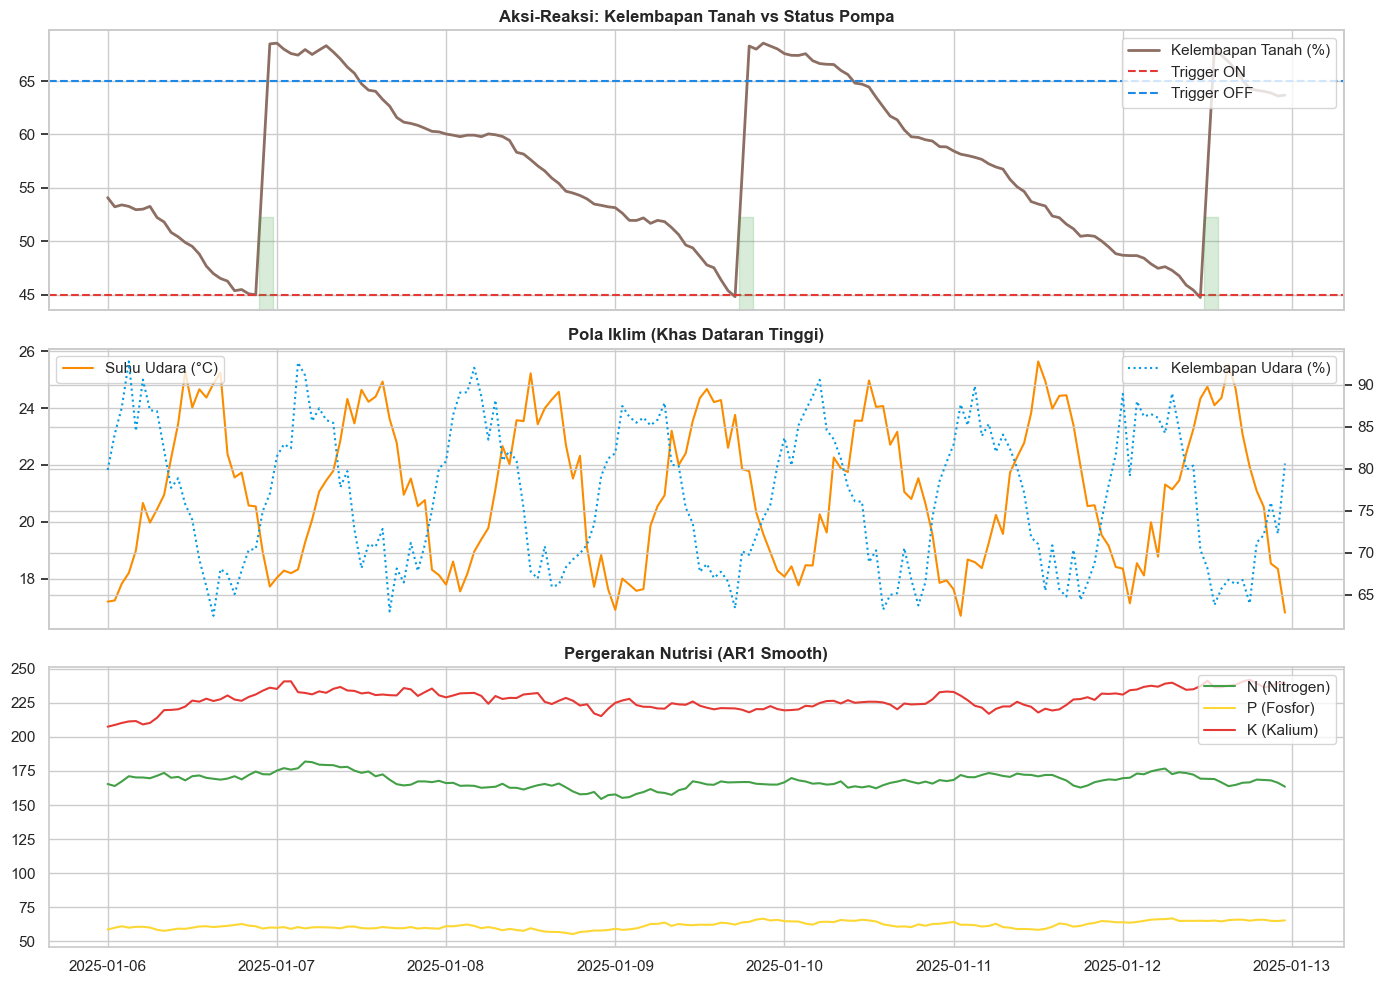

In [16]:
vis_start, vis_end = "2025-01-06", "2025-01-12"
df_vis = df[vis_start:vis_end]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# 1. Kelembapan Tanah vs Pompa
ax1 = axes[0]
ax1.plot(df_vis.index, df_vis['Kelembapan_Tanah'], color='#8D6E63', lw=2, label='Kelembapan Tanah (%)')
ax1.axhline(SOIL_CFG['trigger_low'], color='#E53935', ls='--', label='Trigger ON')
ax1.axhline(SOIL_CFG['trigger_high'], color='#1E88E5', ls='--', label='Trigger OFF')
ax1r = ax1.twinx()
ax1r.fill_between(df_vis.index, df_vis['Status_Pompa'], color='#43A047', alpha=0.2, step='mid', label='Pompa ON')
ax1r.set_ylim(0, 3)
ax1r.set_yticks([])
ax1.set_title("Aksi-Reaksi: Kelembapan Tanah vs Status Pompa", fontweight='bold')
ax1.legend(loc='upper right')

# 2. Suhu & Kelembapan Udara
ax2 = axes[1]
ax2.plot(df_vis.index, df_vis['Suhu_Udara'], color='#FB8C00', label='Suhu Udara (°C)')
ax2r = ax2.twinx()
ax2r.plot(df_vis.index, df_vis['Kelembapan_Udara'], color='#039BE5', ls=':', label='Kelembapan Udara (%)')
ax2.set_title("Pola Iklim (Khas Dataran Tinggi)", fontweight='bold')
ax2.legend(loc='upper left'); ax2r.legend(loc='upper right')

# 3. NPK
ax3 = axes[2]
ax3.plot(df_vis.index, df_vis['N'], color='#43A047', label='N (Nitrogen)')
ax3.plot(df_vis.index, df_vis['P'], color='#FDD835', label='P (Fosfor)')
ax3.plot(df_vis.index, df_vis['K'], color='#E53935', label='K (Kalium)')
ax3.set_title("Pergerakan Nutrisi (AR1 Smooth)", fontweight='bold')
ax3.legend(loc='upper right')

plt.tight_layout()
plt.show()